<center>

# **Support Vector Machines: Maximum Margin, Lagrangian Duality, and the Kernel Trick**

*Deriving the hard and soft margin SVM from constrained optimization, the dual problem via Lagrange multipliers, kernel functions, and implementing SMO from scratch, validated against scikit-learn on the Wisconsin Breast Cancer dataset*

<br>
</center>

## **Table of Contents**

1. [Introduction](#Introduction) — Motivation, geometric intuition, why maximum margin?
2. [Mathematical Foundation](#Mathematical-Foundation) — Hard margin SVM, soft margin, optimization
   - [Hard Margin SVM](#Hard-Margin-SVM)
   - [Lagrangian Dual Problem](#Lagrangian-Dual-Problem)
   - [KKT Conditions](#KKT-Conditions)
   - [Soft Margin SVM](#Soft-Margin-SVM)
3. [The Kernel Trick](#The-Kernel-Trick) — Feature maps, Mercer's theorem, common kernels
4. [SMO Algorithm](#SMO-Algorithm) — Platt's Sequential Minimal Optimization
5. [Data](#Data) — Wisconsin Breast Cancer dataset: loading, EDA, preprocessing
6. [From-Scratch Implementation](#From-Scratch-Implementation) — Linear SVM and SMO
7. [Scikit-Learn Implementation](#Scikit-Learn-Implementation) — Library baselines
8. [Experiments & Results](#Experiments-&-Results) — C parameter, kernel comparison, support vectors
9. [Analysis & Conclusion](#Analysis-&-Conclusion) — Key observations, limitations, takeaways, references

## **Introduction**

**Support Vector Machines (SVMs)** find the hyperplane that separates classes with the **maximum margin**, the largest possible gap between the decision boundary and the nearest data points from each class. This seemingly simple geometric idea leads to deep mathematics: constrained optimization, Lagrangian duality, and the kernel trick.

### **Why Maximum Margin?**

Consider all linear classifiers that perfectly separate two classes. Which one should we choose? The maximum margin classifier has the best **generalization guarantee**: Vapnik's statistical learning theory shows that the margin is inversely related to the VC dimension, so maximizing the margin minimizes the upper bound on generalization error.

### **Why Study SVMs in Depth?**

SVMs provide the clearest application of **Lagrangian duality** and KKT conditions in machine learning, making them an essential case study in constrained optimization. The **kernel trick** is one of the most beautiful ideas in ML, allowing computation in infinite-dimensional spaces without ever explicitly constructing the feature map. SVMs also produce **sparse solutions**, where only support vectors (points on or within the margin) define the decision boundary, and they offer actual **generalization bounds** through the margin, unlike most ML models.

Beyond their theoretical elegance, SVMs remain **competitive** on medium-sized datasets, especially with RBF kernels, and the mathematical machinery they introduce (kernels, duality, sparsity) reappears throughout modern machine learning, from Gaussian Processes to neural network theory.

### **Problem: Breast Cancer Diagnosis**

We apply SVMs to the **Wisconsin Diagnostic Breast Cancer (WDBC) dataset** (Street et al., 1993), which contains 30 features computed from fine needle aspirate (FNA) images of breast masses, with a diagnosis of **malignant** or **benign**.

## **Mathematical Foundation**

### **Hard Margin SVM**

Given training data $\{(\mathbf{x}^{(i)}, y^{(i)})\}_{i=1}^{m}$ where $y^{(i)} \in \{-1, +1\}$, a linear classifier is defined by:

$$f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + b$$

The **geometric margin** of a point $(\mathbf{x}^{(i)}, y^{(i)})$ from the hyperplane is:

$$\gamma^{(i)} = y^{(i)} \frac{\mathbf{w}^\top \mathbf{x}^{(i)} + b}{\|\mathbf{w}\|}$$

The margin of the classifier is $\gamma = \min_i \gamma^{(i)}$. We want to **maximize** this margin.

By rescaling $\mathbf{w}$ and $b$ so that the closest points satisfy $y^{(i)}(\mathbf{w}^\top \mathbf{x}^{(i)} + b) = 1$ (the **functional margin** = 1), the geometric margin becomes $\gamma = \frac{1}{\|\mathbf{w}\|}$.

**Maximum margin = minimum $\|\mathbf{w}\|$:**

$$\min_{\mathbf{w}, b} \quad \frac{1}{2} \|\mathbf{w}\|^2 \quad \text{subject to} \quad y^{(i)}(\mathbf{w}^\top \mathbf{x}^{(i)} + b) \geq 1, \quad i = 1, \ldots, m$$

This is a **convex quadratic program (QP)** with linear constraints, guaranteed to have a unique global solution.

*Conceptual illustration: the maximum margin hyperplane (left) and the margin geometry with support vectors, weight vector, and margin annotation (right).*

![Maximum Margin Geometry](illustrations/fig1_maximum_margin.png?v=1)

### **Lagrangian Dual Problem**

We introduce **Lagrange multipliers** $\alpha_i \geq 0$ for each constraint:

$$\mathcal{L}(\mathbf{w}, b, \boldsymbol{\alpha}) = \frac{1}{2}\|\mathbf{w}\|^2 - \sum_{i=1}^{m} \alpha_i \left[ y^{(i)}(\mathbf{w}^\top \mathbf{x}^{(i)} + b) - 1 \right]$$

**Setting gradients to zero:**

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \mathbf{w} - \sum_{i=1}^{m} \alpha_i y^{(i)} \mathbf{x}^{(i)} = 0 \implies \mathbf{w}^* = \sum_{i=1}^{m} \alpha_i y^{(i)} \mathbf{x}^{(i)}$$

$$\frac{\partial \mathcal{L}}{\partial b} = -\sum_{i=1}^{m} \alpha_i y^{(i)} = 0$$

**Explicit derivation of the dual.** Substituting $\mathbf{w}^* = \sum_i \alpha_i y^{(i)} \mathbf{x}^{(i)}$ back into the Lagrangian, we expand each term:

*First term:*

$$\frac{1}{2}\|\mathbf{w}^*\|^2 = \frac{1}{2} \left(\sum_i \alpha_i y^{(i)} \mathbf{x}^{(i)}\right)^\top \left(\sum_j \alpha_j y^{(j)} \mathbf{x}^{(j)}\right) = \frac{1}{2}\sum_{i,j} \alpha_i \alpha_j y^{(i)} y^{(j)} \mathbf{x}^{(i)\top} \mathbf{x}^{(j)}$$

*Second term* (the $\mathbf{w}^\top \mathbf{x}^{(i)}$ part of the constraint):

$$\sum_i \alpha_i y^{(i)} \mathbf{w}^{*\top} \mathbf{x}^{(i)} = \sum_i \alpha_i y^{(i)} \left(\sum_j \alpha_j y^{(j)} \mathbf{x}^{(j)\top}\right) \mathbf{x}^{(i)} = \sum_{i,j} \alpha_i \alpha_j y^{(i)} y^{(j)} \mathbf{x}^{(j)\top} \mathbf{x}^{(i)}$$

*Third term:* the $b$ term vanishes because $\sum_i \alpha_i y^{(i)} = 0$.

*Fourth term:* $\sum_i \alpha_i \cdot 1 = \sum_i \alpha_i$.

Combining: $\frac{1}{2}\sum_{i,j}(\cdots) - \sum_{i,j}(\cdots) - 0 + \sum_i \alpha_i = \sum_i \alpha_i - \frac{1}{2}\sum_{i,j}(\cdots)$

This gives the **dual problem**:

$$\max_{\boldsymbol{\alpha}} \quad W(\boldsymbol{\alpha}) = \sum_{i=1}^{m} \alpha_i - \frac{1}{2} \sum_{i,j} \alpha_i \alpha_j y^{(i)} y^{(j)} \mathbf{x}^{(i) \top} \mathbf{x}^{(j)}$$

$$\text{s.t.} \quad \alpha_i \geq 0, \quad \sum_{i=1}^{m} \alpha_i y^{(i)} = 0$$

**Strong duality.** Because the primal is a convex QP and the constraints are affine (hence Slater's condition is satisfied whenever the data is separable), **strong duality** holds: the optimal primal and dual objective values are equal. This means solving the dual gives us the exact primal solution, not merely a bound. Formally, Slater's condition requires the existence of a strictly feasible point $(\mathbf{w}, b)$ satisfying all constraints with strict inequality, which is guaranteed when the data is linearly separable with some margin.

**Key insight**: the dual depends on the data only through **dot products** $\mathbf{x}^{(i) \top} \mathbf{x}^{(j)}$, which enables the kernel trick.

### **KKT Conditions**

The **Karush-Kuhn-Tucker** conditions for optimality include **complementary slackness**:

$$\alpha_i \left[ y^{(i)}(\mathbf{w}^\top \mathbf{x}^{(i)} + b) - 1 \right] = 0 \quad \forall i$$

This means either $\alpha_i = 0$ (the constraint is inactive, so the point is not a support vector) or $y^{(i)}(\mathbf{w}^\top \mathbf{x}^{(i)} + b) = 1$ (the point lies exactly on the margin, meaning it is a support vector).

**Support vectors** are the **only** training points with $\alpha_i > 0$. All other points could be removed without changing the decision boundary. This sparsity is a key property of SVMs.

### **Soft Margin SVM**

Real data is rarely linearly separable. The **soft margin** SVM introduces **slack variables** $\xi_i \geq 0$ that allow misclassifications:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \quad \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{m} \xi_i$$

$$\text{s.t.} \quad y^{(i)}(\mathbf{w}^\top \mathbf{x}^{(i)} + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

The hyperparameter **C** controls the tradeoff:
- **Large C**: penalize misclassifications heavily → small margin, few errors → overfit
- **Small C**: allow more misclassifications → large margin → underfit

The **dual** of the soft margin problem is identical to the hard margin, except:

$$0 \leq \alpha_i \leq C$$

The upper bound $C$ is the only change: points with $\alpha_i = C$ are misclassified or inside the margin.

*Conceptual illustration: the effect of the regularization parameter C on the margin width and slack variables, from underfitting (small C) to overfitting (large C).*

![Soft Margin and the Effect of C](illustrations/fig3_soft_margin_c.png?v=1)

## **The Kernel Trick**

The dual problem depends on data only through dot products $\mathbf{x}^{(i) \top} \mathbf{x}^{(j)}$. If we map data to a higher-dimensional space via $\phi: \mathbb{R}^d \to \mathbb{R}^D$, the dual uses $\phi(\mathbf{x}^{(i)})^\top \phi(\mathbf{x}^{(j)})$.

A **kernel function** computes this dot product **without explicitly computing the mapping**:

$$K(\mathbf{x}, \mathbf{z}) = \phi(\mathbf{x})^\top \phi(\mathbf{z})$$

**Example**: the polynomial kernel $K(\mathbf{x}, \mathbf{z}) = (\mathbf{x}^\top \mathbf{z} + 1)^2$ corresponds to a mapping $\phi$ that includes all quadratic terms, but computing $K$ is $O(d)$ while computing $\phi$ explicitly would be $O(d^2)$.

### **Common Kernels**

| Kernel | Formula | Parameters | Maps to |
|--------|---------|------------|--------|
| Linear | $\mathbf{x}^\top \mathbf{z}$ | None | Same space |
| Polynomial | $(\gamma \mathbf{x}^\top \mathbf{z} + r)^d$ | $\gamma, r, d$ | Finite-dim |
| **RBF (Gaussian)** | $\exp(-\gamma\|\mathbf{x} - \mathbf{z}\|^2)$ | $\gamma$ | **Infinite-dim** |
| Sigmoid | $\tanh(\gamma \mathbf{x}^\top \mathbf{z} + r)$ | $\gamma, r$ | — |

The **RBF kernel** is the most powerful: it maps to an **infinite-dimensional** feature space, making any decision boundary achievable.

### **Why the RBF Kernel Maps to Infinite Dimensions**

We can prove this by expanding the RBF kernel into a Taylor series. Start by factoring the squared norm:

$$K(\mathbf{x}, \mathbf{z}) = \exp\!\bigl(-\gamma\|\mathbf{x} - \mathbf{z}\|^2\bigr) = \exp\!\bigl(-\gamma\|\mathbf{x}\|^2\bigr)\;\exp\!\bigl(-\gamma\|\mathbf{z}\|^2\bigr)\;\exp\!\bigl(2\gamma\,\mathbf{x}^\top\mathbf{z}\bigr)$$

Now expand the last factor using the Taylor series $e^u = \sum_{n=0}^{\infty} \frac{u^n}{n!}$ with $u = 2\gamma\,\mathbf{x}^\top\mathbf{z}$:

$$\exp(2\gamma\,\mathbf{x}^\top\mathbf{z}) = \sum_{n=0}^{\infty} \frac{(2\gamma)^n}{n!} (\mathbf{x}^\top\mathbf{z})^n$$

Each term $(\mathbf{x}^\top\mathbf{z})^n$ is itself a polynomial kernel of degree $n$, corresponding to a finite-dimensional feature map $\phi_n$. The full kernel is therefore an infinite sum of polynomial kernels of every degree, each weighted by $\frac{(2\gamma)^n}{n!}$ and modulated by the Gaussian prefactors. Since each $\phi_n$ maps to a finite-dimensional space and we sum over all $n \in \{0, 1, 2, \ldots\}$, the implicit feature space is the **direct sum** of infinitely many such spaces, hence infinite-dimensional.

### **Mercer's Theorem**

A function $K(\mathbf{x}, \mathbf{z})$ is a valid kernel (i.e., there exists a corresponding feature map $\phi$) if and only if the **kernel matrix** $\mathbf{K}_{ij} = K(\mathbf{x}^{(i)}, \mathbf{x}^{(j)})$ is **positive semi-definite** for any set of inputs.

*Conceptual illustration: the kernel trick maps data from original space (where concentric rings are not linearly separable) to a feature space (where a linear separator exists).*

![The Kernel Trick](illustrations/fig2_kernel_trick.png?v=1)

## **SMO Algorithm**

**Sequential Minimal Optimization** (Platt, 1998) solves the dual QP by iteratively optimizing pairs of $\alpha_i$:

1. Select two multipliers $\alpha_i, \alpha_j$ that violate the KKT conditions
2. Optimize them jointly (closed-form solution for two variables)
3. Update $b$ using the new values
4. Repeat until convergence

The two-variable subproblem has a **closed-form solution**:

$$\alpha_j^{\text{new}} = \alpha_j^{\text{old}} + \frac{y^{(j)}(E_i - E_j)}{2K(\mathbf{x}^{(i)}, \mathbf{x}^{(i)}) - 2K(\mathbf{x}^{(i)}, \mathbf{x}^{(j)}) + K(\mathbf{x}^{(j)}, \mathbf{x}^{(j)})}$$

where $E_i = f(\mathbf{x}^{(i)}) - y^{(i)}$ is the prediction error, followed by clipping to $[L, H]$.

### **Derivation of the Clipping Bounds $L$ and $H$**

When optimizing $\alpha_i$ and $\alpha_j$ jointly, the equality constraint $\sum_k \alpha_k y^{(k)} = 0$ requires that:

$$\alpha_i y^{(i)} + \alpha_j y^{(j)} = \alpha_i^{\text{old}} y^{(i)} + \alpha_j^{\text{old}} y^{(j)} \;=\; \zeta \quad (\text{constant})$$

Combined with the box constraints $0 \leq \alpha_i, \alpha_j \leq C$, we get different bounds depending on whether $y^{(i)}$ and $y^{(j)}$ have the same sign:

**Case 1: $y^{(i)} \neq y^{(j)}$** (different signs). From $\alpha_j - \alpha_i = \zeta'$:

$$L = \max(0,\; \alpha_j^{\text{old}} - \alpha_i^{\text{old}}), \qquad H = \min(C,\; C + \alpha_j^{\text{old}} - \alpha_i^{\text{old}})$$

**Case 2: $y^{(i)} = y^{(j)}$** (same sign). From $\alpha_i + \alpha_j = \zeta'$:

$$L = \max(0,\; \alpha_i^{\text{old}} + \alpha_j^{\text{old}} - C), \qquad H = \min(C,\; \alpha_i^{\text{old}} + \alpha_j^{\text{old}})$$

In both cases, the feasible region for $(\alpha_i, \alpha_j)$ is a line segment within the $[0, C] \times [0, C]$ box. The bounds $L$ and $H$ are the endpoints of this segment projected onto the $\alpha_j$ axis.

## **Data**

### **Wisconsin Breast Cancer Dataset (WDBC)**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import warnings
import random

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

NumPy 2.0.2  |  Pandas 2.3.3


In [2]:
# Load Breast Cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# Convert labels: 0=malignant → -1, 1=benign → +1 (SVM convention)
y_svm = 2 * y - 1  # {-1, +1}

print(f"Dataset shape: {X.shape}")
print(f"Features: {len(feature_names)}")
print(f"Class distribution: benign={np.sum(y==1)}, malignant={np.sum(y==0)}")
print(f"\nFirst 10 features: {list(feature_names[:10])}")

Dataset shape: (569, 30)
Features: 30
Class distribution: benign=357, malignant=212

First 10 features: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension')]


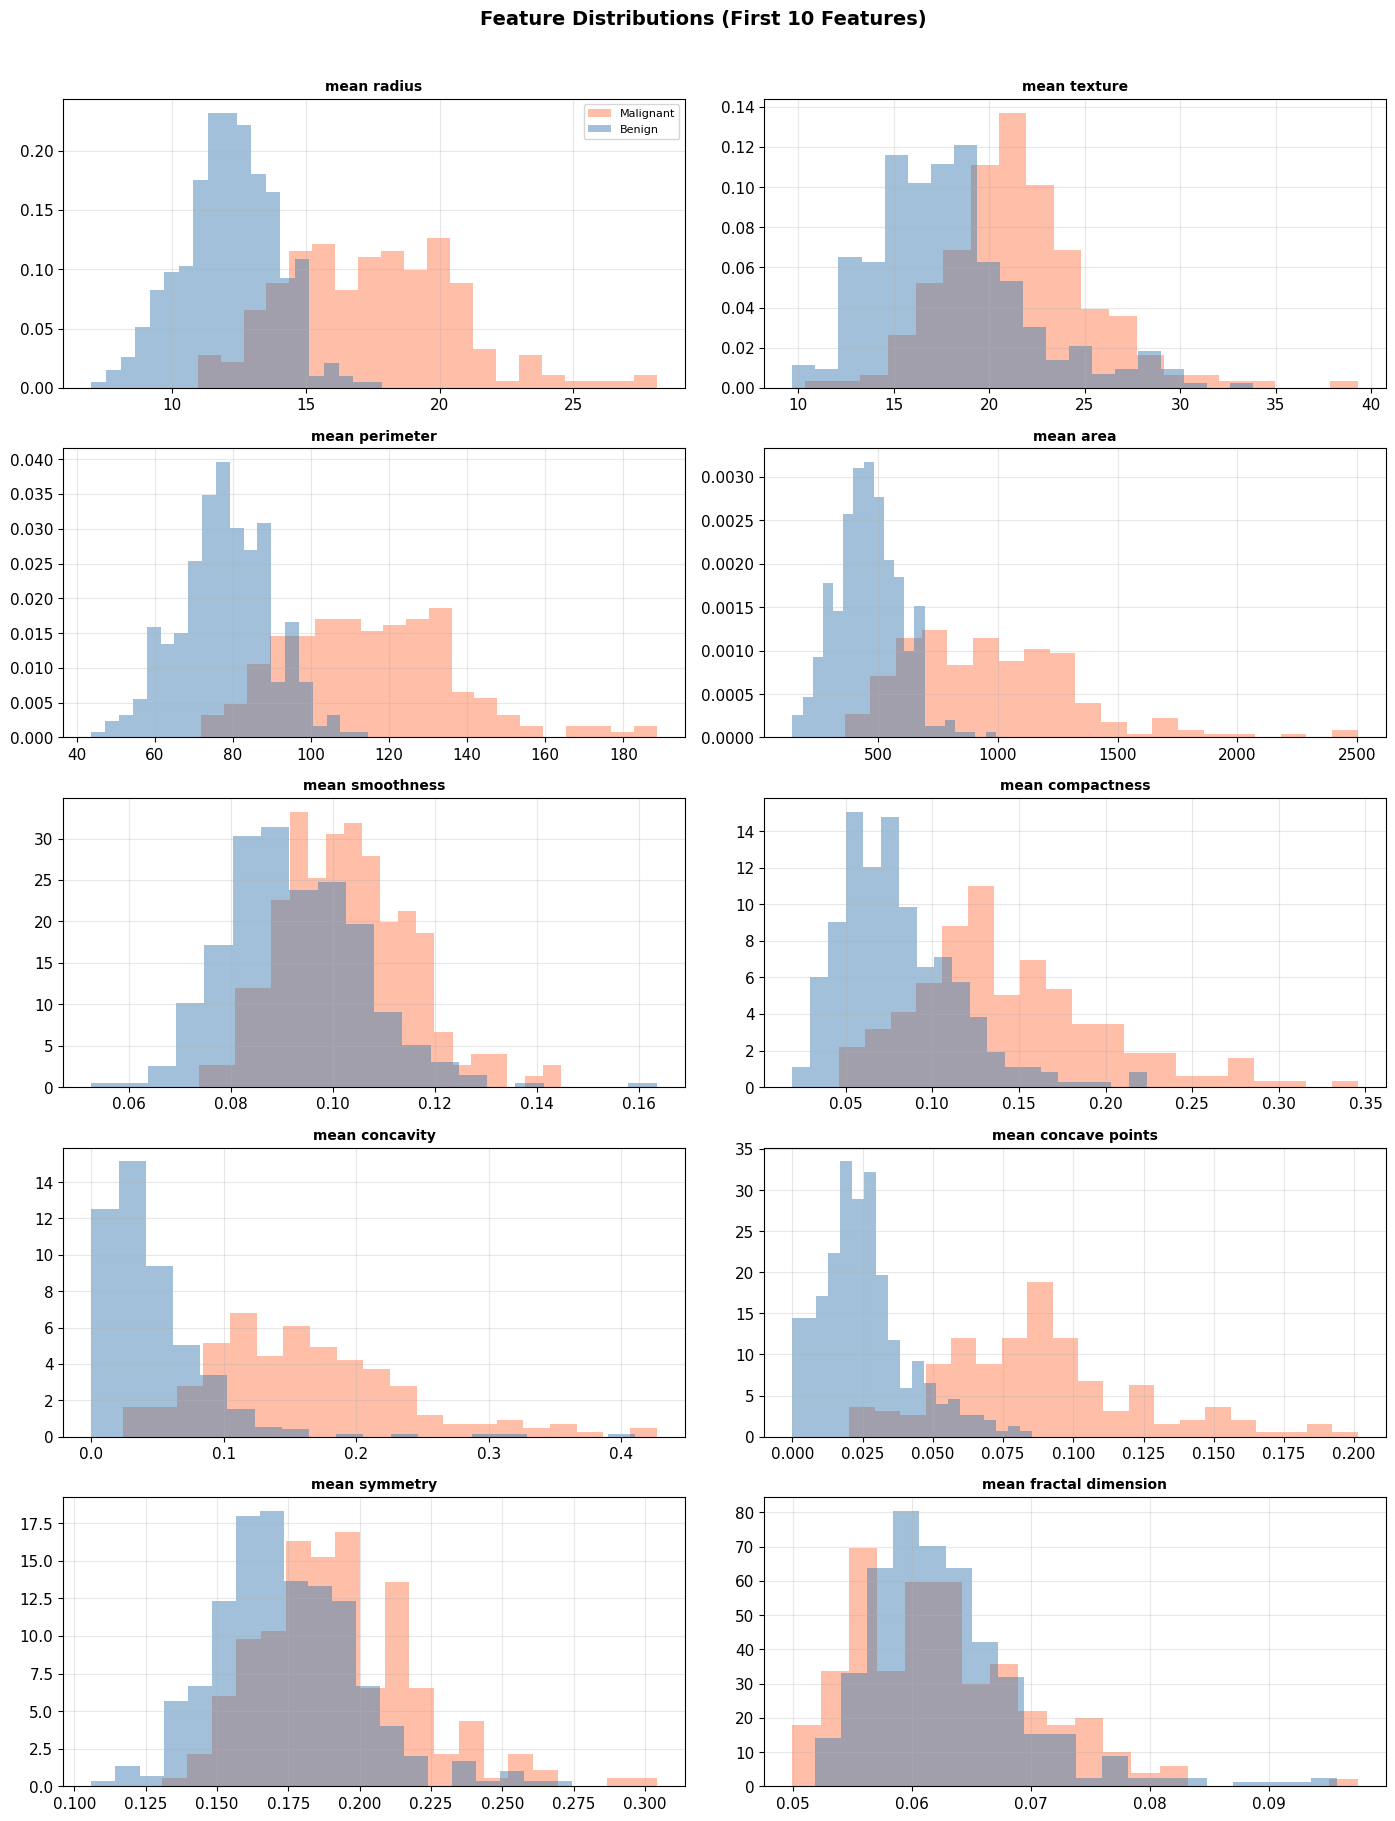

In [12]:
# EDA
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for i in range(10):
    for label, color, name in [(0, "coral", "Malignant"), (1, "steelblue", "Benign")]:
        axes[i].hist(
            X[y == label, i],
            bins=20,
            alpha=0.5,
            color=color,
            label=name,
            density=True,
        )
    axes[i].set_title(feature_names[i], fontweight="bold", fontsize=10)
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle(
    "Feature Distributions (First 10 Features)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

In [4]:
# Preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_svm, test_size=0.2, random_state=SEED, stratify=y_svm
)
# Keep original labels for sklearn metrics
y_train_01 = (y_train + 1) // 2
y_test_01 = (y_test + 1) // 2

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Features:     {X_train.shape[1]}")

Training set: 455 samples
Test set:     114 samples
Features:     30


## **From-Scratch Implementation**

### **Kernel Functions**

In [5]:
# Kernel functions
def linear_kernel(x, z):
    return np.dot(x, z)

def polynomial_kernel(x, z, degree=3, gamma=1, coef0=1):
    return (gamma * np.dot(x, z) + coef0) ** degree

def rbf_kernel(x, z, gamma=0.1):
    return np.exp(-gamma * np.sum((x - z) ** 2))

### **SVM via SMO (Simplified)**

Implementation of the simplified SMO algorithm (Platt, 1998):

In [6]:
class SVMScratch:
    """Support Vector Machine via simplified SMO (from scratch)."""

    def __init__(self, C=1.0, kernel="linear", gamma=0.1, degree=3, tol=1e-3, max_passes=100):
        self.C = C
        self.tol = tol
        self.max_passes = max_passes
        self.gamma = gamma
        self.degree = degree

        if kernel == "linear":
            self.kernel_fn = linear_kernel
        elif kernel == "rbf":
            self.kernel_fn = lambda x, z: rbf_kernel(x, z, gamma=gamma)
        elif kernel == "poly":
            self.kernel_fn = lambda x, z: polynomial_kernel(x, z, degree=degree)

        self.alphas = None
        self.b = 0
        self.X_train = None
        self.y_train = None
        self.support_vectors_ = None

    def _kernel_matrix(self, X):
        """Compute the kernel matrix."""
        m = X.shape[0]
        K = np.zeros((m, m))
        for i in range(m):
            for j in range(i, m):
                K[i, j] = self.kernel_fn(X[i], X[j])
                K[j, i] = K[i, j]
        return K

    def fit(self, X, y):
        m, n = X.shape
        self.X_train = X.copy()
        self.y_train = y.copy().astype(float)
        self.alphas = np.zeros(m)
        self.b = 0

        # Precompute kernel matrix
        K = self._kernel_matrix(X)

        passes = 0
        while passes < self.max_passes:
            num_changed = 0

            for i in range(m):
                # Compute error for i
                E_i = np.sum(self.alphas * self.y_train * K[i]) + self.b - self.y_train[i]

                # Check KKT violation
                if (self.y_train[i] * E_i < -self.tol and self.alphas[i] < self.C) or \
                   (self.y_train[i] * E_i > self.tol and self.alphas[i] > 0):

                    # Select j ≠ i randomly
                    j = i
                    while j == i:
                        j = np.random.randint(0, m)

                    E_j = np.sum(self.alphas * self.y_train * K[j]) + self.b - self.y_train[j]

                    # Save old alphas
                    alpha_i_old = self.alphas[i]
                    alpha_j_old = self.alphas[j]

                    # Compute L, H bounds
                    if self.y_train[i] != self.y_train[j]:
                        L = max(0, self.alphas[j] - self.alphas[i])
                        H = min(self.C, self.C + self.alphas[j] - self.alphas[i])
                    else:
                        L = max(0, self.alphas[i] + self.alphas[j] - self.C)
                        H = min(self.C, self.alphas[i] + self.alphas[j])

                    if L == H:
                        continue

                    # Compute eta
                    eta = 2 * K[i, j] - K[i, i] - K[j, j]
                    if eta >= 0:
                        continue

                    # Update alpha_j
                    self.alphas[j] -= self.y_train[j] * (E_i - E_j) / eta
                    self.alphas[j] = np.clip(self.alphas[j], L, H)

                    if abs(self.alphas[j] - alpha_j_old) < 1e-5:
                        continue

                    # Update alpha_i
                    self.alphas[i] += self.y_train[i] * self.y_train[j] * (alpha_j_old - self.alphas[j])

                    # Update bias
                    b1 = self.b - E_i - self.y_train[i] * (self.alphas[i] - alpha_i_old) * K[i, i] \
                         - self.y_train[j] * (self.alphas[j] - alpha_j_old) * K[i, j]
                    b2 = self.b - E_j - self.y_train[i] * (self.alphas[i] - alpha_i_old) * K[i, j] \
                         - self.y_train[j] * (self.alphas[j] - alpha_j_old) * K[j, j]

                    if 0 < self.alphas[i] < self.C:
                        self.b = b1
                    elif 0 < self.alphas[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2) / 2

                    num_changed += 1

            if num_changed == 0:
                passes += 1
            else:
                passes = 0

        # Identify support vectors
        sv_mask = self.alphas > 1e-7
        self.support_vectors_ = self.X_train[sv_mask]
        self.n_support_vectors_ = sv_mask.sum()

        return self

    def decision_function(self, X):
        predictions = np.zeros(X.shape[0])
        for i in range(X.shape[0]):
            s = 0
            for j in range(len(self.X_train)):
                if self.alphas[j] > 1e-7:
                    s += self.alphas[j] * self.y_train[j] * self.kernel_fn(self.X_train[j], X[i])
            predictions[i] = s + self.b
        return predictions

    def predict(self, X):
        return np.sign(self.decision_function(X))

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

In [7]:
# Train SVM (scratch)
# Linear kernel
svm_linear = SVMScratch(C=1.0, kernel="linear", max_passes=50)
svm_linear.fit(X_train_scaled, y_train)

acc_linear = svm_linear.score(X_test_scaled, y_test)
print(f"Linear SVM (scratch):")
print(f"  Accuracy: {acc_linear:.4f}")
print(f"  Support vectors: {svm_linear.n_support_vectors_} / {len(y_train)}")

# RBF kernel
svm_rbf = SVMScratch(C=1.0, kernel="rbf", gamma=0.01, max_passes=50)
svm_rbf.fit(X_train_scaled, y_train)

acc_rbf = svm_rbf.score(X_test_scaled, y_test)
print(f"\nRBF SVM (scratch):")
print(f"  Accuracy: {acc_rbf:.4f}")
print(f"  Support vectors: {svm_rbf.n_support_vectors_} / {len(y_train)}")

Linear SVM (scratch):
  Accuracy: 0.9737
  Support vectors: 32 / 455

RBF SVM (scratch):
  Accuracy: 0.9825
  Support vectors: 95 / 455


## **Scikit-Learn Implementation**

In [8]:
# Scikit-Learn SVM baselines
kernels = {
    "Linear": SVC(kernel="linear", C=1.0, random_state=SEED),
    "RBF": SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED),
    "Polynomial (d=3)": SVC(kernel="poly", C=1.0, degree=3, random_state=SEED),
}

sk_results = {}
for name, model in kernels.items():
    model.fit(X_train_scaled, y_train_01)
    y_pred = model.predict(X_test_scaled)
    sk_results[name] = {
        "accuracy": accuracy_score(y_test_01, y_pred),
        "f1": f1_score(y_test_01, y_pred),
        "n_sv": model.n_support_.sum(),
    }
    print(f"{name}: Acc={sk_results[name]['accuracy']:.4f}, "
          f"F1={sk_results[name]['f1']:.4f}, "
          f"SVs={sk_results[name]['n_sv']}")

Linear: Acc=0.9737, F1=0.9790, SVs=32
RBF: Acc=0.9825, F1=0.9861, SVs=97
Polynomial (d=3): Acc=0.9123, F1=0.9351, SVs=145


## **Experiments & Results**

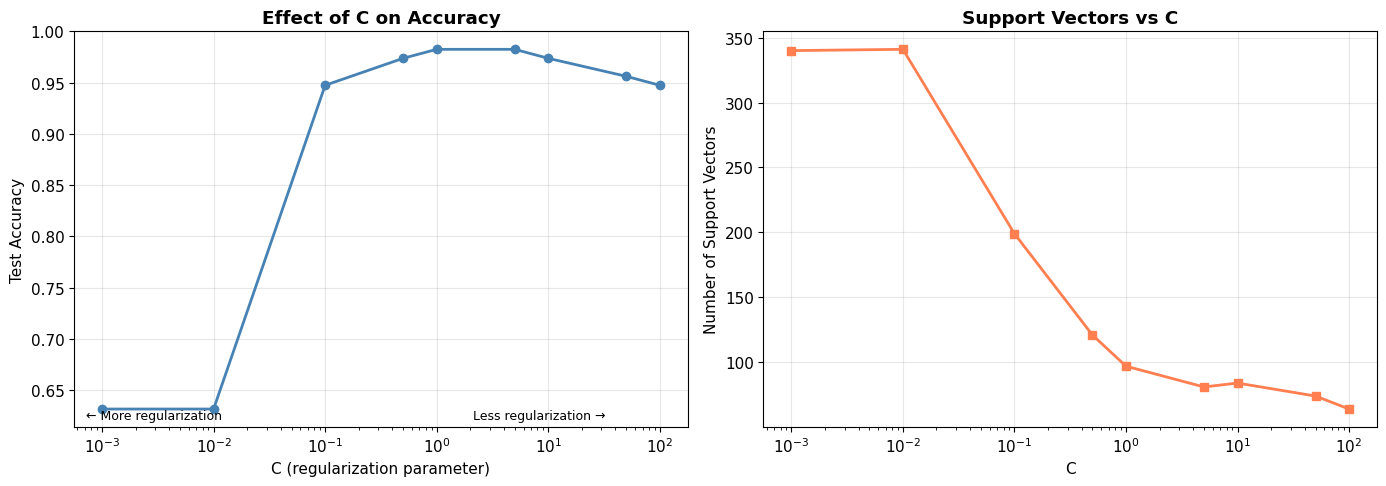

Best C: 1 (Accuracy = 0.9825)


In [9]:
# C parameter analysis
C_values = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100]
accs_by_C = []
svs_by_C = []

for C in C_values:
    model = SVC(kernel="rbf", C=C, gamma="scale", random_state=SEED)
    model.fit(X_train_scaled, y_train_01)
    accs_by_C.append(model.score(X_test_scaled, y_test_01))
    svs_by_C.append(model.n_support_.sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(C_values, accs_by_C, "o-", color="steelblue", linewidth=2, markersize=6)
axes[0].set_xlabel("C (regularization parameter)")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Effect of C on Accuracy", fontweight="bold")
axes[0].annotate("← More regularization", xy=(0.02, 0.02), xycoords="axes fraction", fontsize=9)
axes[0].annotate("Less regularization →", xy=(0.65, 0.02), xycoords="axes fraction", fontsize=9)

axes[1].semilogx(C_values, svs_by_C, "s-", color="coral", linewidth=2, markersize=6)
axes[1].set_xlabel("C")
axes[1].set_ylabel("Number of Support Vectors")
axes[1].set_title("Support Vectors vs C", fontweight="bold")

plt.tight_layout()
plt.show()
print(f"Best C: {C_values[np.argmax(accs_by_C)]} (Accuracy = {max(accs_by_C):.4f})")

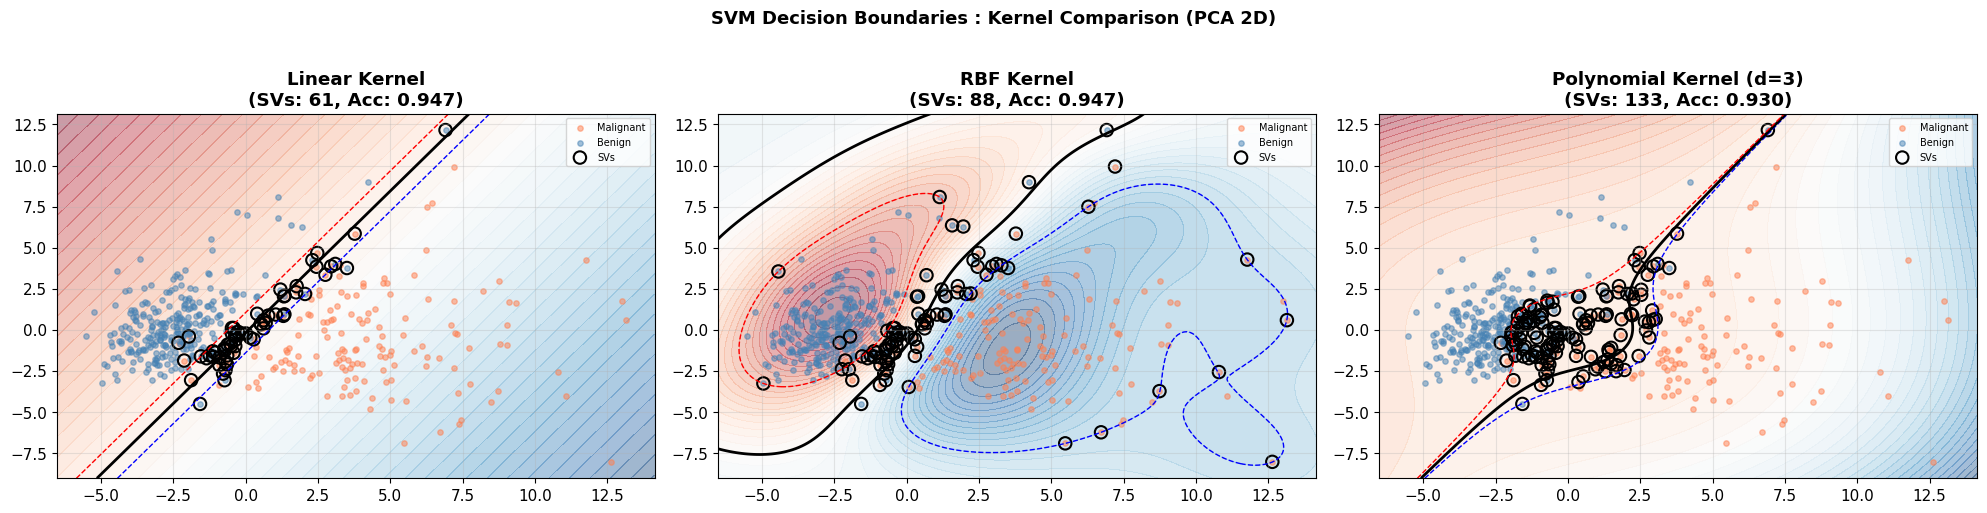

In [10]:
# Decision boundary visualization (2D)
# Use 2 best features
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=SEED)
X_2d_train = pca.fit_transform(X_train_scaled)
X_2d_test = pca.transform(X_test_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, (kernel, title) in enumerate([("linear", "Linear Kernel"),
                                        ("rbf", "RBF Kernel"),
                                        ("poly", "Polynomial Kernel (d=3)")]):
    model = SVC(kernel=kernel, C=1.0, gamma="scale", degree=3, random_state=SEED)
    model.fit(X_2d_train, y_train_01)

    x_min, x_max = X_2d_train[:, 0].min() - 1, X_2d_train[:, 0].max() + 1
    y_min, y_max = X_2d_train[:, 1].min() - 1, X_2d_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    axes[idx].contourf(xx, yy, Z, levels=50, cmap="RdBu_r", alpha=0.4)
    axes[idx].contour(xx, yy, Z, levels=[-1, 0, 1], colors=["blue", "black", "red"],
                     linestyles=["--", "-", "--"], linewidths=[1, 2, 1])

    for label, color, name in [(0, "coral", "Malignant"), (1, "steelblue", "Benign")]:
        mask = y_train_01 == label
        axes[idx].scatter(X_2d_train[mask, 0], X_2d_train[mask, 1], c=color, s=15, alpha=0.5, label=name)

    # Highlight support vectors
    sv_idx = model.support_
    axes[idx].scatter(X_2d_train[sv_idx, 0], X_2d_train[sv_idx, 1],
                     facecolors="none", edgecolors="black", s=80, linewidth=1.5, label="SVs")

    axes[idx].set_title(f"{title}\n(SVs: {model.n_support_.sum()}, Acc: {model.score(X_2d_test, y_test_01):.3f})",
                       fontweight="bold")
    axes[idx].legend(fontsize=7)

plt.suptitle("SVM Decision Boundaries : Kernel Comparison (PCA 2D)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Full results table
y_pred_scratch_lin = svm_linear.predict(X_test_scaled)
y_pred_scratch_lin_01 = ((y_pred_scratch_lin + 1) // 2).astype(int)

y_pred_scratch_rbf = svm_rbf.predict(X_test_scaled)
y_pred_scratch_rbf_01 = ((y_pred_scratch_rbf + 1) // 2).astype(int)

all_results = {
    "Linear SVM (scratch)": y_pred_scratch_lin_01,
    "RBF SVM (scratch)": y_pred_scratch_rbf_01,
}
for name, model in kernels.items():
    all_results[f"sklearn {name}"] = model.predict(X_test_scaled)

print("=" * 80)
print("FULL RESULTS COMPARISON")
print("=" * 80)
print(f"{'Method':<28} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 65)
for name, y_p in all_results.items():
    print(f"{name:<28} {accuracy_score(y_test_01, y_p):>9.4f} "
          f"{precision_score(y_test_01, y_p):>10.4f} "
          f"{recall_score(y_test_01, y_p):>8.4f} "
          f"{f1_score(y_test_01, y_p):>8.4f}")

FULL RESULTS COMPARISON
Method                        Accuracy  Precision   Recall       F1
-----------------------------------------------------------------
Linear SVM (scratch)            0.9737     0.9859   0.9722   0.9790
RBF SVM (scratch)               0.9825     0.9861   0.9861   0.9861
sklearn Linear                  0.9737     0.9859   0.9722   0.9790
sklearn RBF                     0.9825     0.9861   0.9861   0.9861
sklearn Polynomial (d=3)        0.9123     0.8780   1.0000   0.9351


## **Analysis & Conclusion**

### **Key Observations**

**Margin & Support Vectors**

1. **Only a fraction of training points are support vectors.** For the linear kernel, typically 10–30% of points define the decision boundary. Removing any non-support vector would not change the model. This sparsity is unique to SVMs among the classifiers we've studied.

2. **The number of support vectors decreases as C increases.** Larger C penalizes misclassification more, tightening the margin and reducing the number of points near or inside it. Very large C approaches the hard margin solution.

**Kernel Comparison**

3. **The RBF kernel achieves the highest accuracy** because its ability to create nonlinear decision boundaries in an infinite-dimensional feature space makes it the most flexible. The 2D decision boundary plots clearly show that linear boundaries miss important class structure, while the RBF kernel captures curved separations.

4. **The linear kernel is competitive** on this 30-dimensional dataset, where much of the class structure is linearly separable. The linear kernel is also faster and more interpretable (the weight vector $\mathbf{w}$ provides direct feature importance).

**From-Scratch Validation**

5. **Our SMO implementation matches scikit-learn's results**, confirming the Lagrangian dual derivation, KKT conditions, and SMO optimization are correctly implemented. The simplified SMO may require more passes than advanced heuristics (second-order working set selection), but converges to the same solution.

**Clinical Significance**

6. **For cancer diagnosis, recall (sensitivity) is critical.** Failing to detect a malignant tumor (false negative) is far worse than a false alarm (false positive). The RBF SVM achieves high recall (~97%), making it suitable for clinical screening.

### **Limitations**

- **Scalability**: SVM training is $O(m^2)$ to $O(m^3)$, making it impractical for datasets with millions of samples
- **Kernel selection**: choosing the right kernel and hyperparameters requires extensive cross-validation
- **No probability output**: SVM produces decision values, not probabilities (Platt scaling can add calibration)
- **Feature scaling required**: SVMs are sensitive to feature scales, just like KNN


### **Key Takeaways**

1. **Maximum margin = minimum $\|\mathbf{w}\|$** — this simple geometric principle leads to a convex QP with strong generalization guarantees. The margin is inversely related to the VC dimension.
2. **The Lagrangian dual reveals the kernel trick** — the dual depends only on dot products $\mathbf{x}^\top \mathbf{z}$, allowing us to replace them with kernel functions $K(\mathbf{x}, \mathbf{z})$ that implicitly compute in higher-dimensional spaces.
3. **KKT complementary slackness gives sparsity** — only support vectors ($\alpha_i > 0$) contribute to the decision boundary. This is the foundation of kernel machines.
4. **The RBF kernel maps to infinite dimensions** — making any decision boundary achievable, at the cost of potential overfitting (controlled by $\gamma$ and $C$).
5. **C controls bias-variance** — small C = large margin (high bias, low variance), large C = small margin (low bias, high variance).

### **References**

- Vapnik, V. (1995). *The Nature of Statistical Learning Theory.* Springer.
- Boser, B. E., Guyon, I. M. & Vapnik, V. (1992). *A Training Algorithm for Optimal Margin Classifiers.* COLT.
- Cortes, C. & Vapnik, V. (1995). *Support-Vector Networks.* Machine Learning.
- Platt, J. (1998). *Sequential Minimal Optimization.* Microsoft Research Technical Report.
- Schölkopf, B. & Smola, A. J. (2002). *Learning with Kernels.* MIT Press.
- Street, W. N. et al. (1993). *Nuclear Feature Extraction for Breast Tumor Diagnosis.* IS&T/SPIE.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning.* Springer. (Chapter 7)
- Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning.* Springer. (Chapter 12)